# Executive Summary
Churn is a critical problem for TelcoConnect. Churn refers to the number of customers who cease doing business with a company within a given period.
This project analyzes a dataset of Telco customers to uncover individual customer behaviour to understand customer churn rates, what is driving it and what can be done to prevent customer churn and retain them.

### Business Context
TelcoConnect is facing a critical challenge. It is facing high customer churn, especially among new subscribers. This trend leads to significant revenue loss and increased customer acquisition costs. Marketing department and Customer success deaprtment wants to understand the drivers of churn and who is most likely to churn so that they can design a plan for effective retention strategies and improving customer lifetime value which will save company huge amount of money in long run.


### Project Objectives
- Identify key factors contributing to customer churn.
- Build a predictive model to flag customers at high risk of churning.
- Provide actionable recommendations to marketing team and customer success department to reduce churn and improve retention.

### Key Techniques Applied
- Exploratory Data Analysis (EDA): Uncovered patterns in tenure, contract types, billing, and customer type.
- Feature Engineering: Encoded categorical variables, created tenure bins and interaction features.
- Modeling: Logistic Regression, Random Forest, XGBoost and KNN to predict churn.
- Evaluation Metrics: ROC-AUC, F1 Score, Precision, Recall to assess model performance.
  
### Business Problem/Insights
- Churn is disproportionately high among customers with short tenure and monthly contracts.
- Billing method and service combinations may influence churn.
- Demographic factors such as age(young or senior citizen) might play a role in churn
- Predict which customer will churn so that, Marketing team and customer success team can stratagiese on plan to retain them.

### Findings
- If tenure is less than 1 year then customer is most likely to churn.
- Customers on month-to-month payment plan are at high-risk of churning than to those on 1-year or 2-year contract.
- Customers with low engagement score are highly likely to churn as well.
- Young customers are more likely to churn than senior citizen, potentially because looking for better deals elsewhere. While senior citizen might feel safe being with a brand over long period.

### Recommendations
- Run retention campaigns aggresively and target monthly contract holders with loyalty incentives,free services like data and bundled offers, since they are highly likely to churn. Focus more on customers flagged by the model as hihg-risk to be churned.
- Customer success team must make onboarding process improvements to enhance early customer experience which might help to reduce short-tenure churn.
- Optimise billing process to offer flexible payment plans and highlight cost-saving bundles.
- Use the model to flag high-risk customers daily/weekly and trigger retention workflows from customer success team.



In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, roc_curve, confusion_matrix)

## 1. Load dataset

In [2]:
url = "https://drive.google.com/uc?export=download&id=1R2aKl_WSmGo0SryqCQnMNztzH5aMdIEM"
df = pd.read_csv(url)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,1,Yes,Yes,30.0,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,No,Electronic check,74.85,2245.5,No
69996,CUST69997,Male,0,Yes,NaN,15.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),40.67,610.05,Yes
69997,CUST69998,Male,0,NaN,No,20.0,Yes,No,DSL,Yes,...,No,No,NaN,No,Month-to-month,Yes,Mailed check,29.44,588.8,No
69998,CUST69999,Male,0,No,No,21.0,Yes,No,Fiber optic,No,...,No,No,Yes,No internet service,Month-to-month,Yes,Electronic check,46.77,982.17,No


In [3]:
df.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


## 2. Data Cleaning

In [4]:
# Check for missing values
df.isnull().sum()

customerID             0
gender               748
SeniorCitizen        659
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

#### 2.1 Clean Gender

In [5]:
# Value count gender column
df["gender"].value_counts()

gender
Female    34110
Male      33252
Man         500
male        374
FEMALE      351
m           339
f           326
Name: count, dtype: int64

In [6]:
# Fix inconsistant gender values
df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "Male": "Male",
    "Man": "Male",
    "f": "Female",
    "female": "Female",
    "FEMALE": "Female",
    "Woman": "Female",
    "M": "Male",
    "F": "Female"
})

df["gender"].value_counts()

gender
Female    34787
Male      34465
Name: count, dtype: int64

In [7]:
#checking for NaN value on gender column
df["gender"].isna().sum()

np.int64(748)

In [8]:
#replacing NaN with "Unknown"
df["gender"].fillna("Unknown", inplace=True)
df["gender"].isna().sum()

C:\Users\kapil\AppData\Local\Temp\ipykernel_12576\287516740.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].fillna("Unknown", inplace=True)


np.int64(0)

#### 2.2 Clean Senior Citizen

In [9]:
#value count senior citizen column
df["SeniorCitizen"].value_counts()

SeniorCitizen
0             52405
1             10388
Yes            3559
No             2739
not senior      250
Name: count, dtype: int64

In [10]:
#Fix inconsistant values
df["SeniorCitizen"] = df["SeniorCitizen"].replace({
    "Yes": "Yes",
    "No": "No",
    "not senior": "No",
    "1": "Yes",
    "0": "No"
})

df["SeniorCitizen"].value_counts()

SeniorCitizen
No     55394
Yes    13947
Name: count, dtype: int64

In [11]:
#checking for NaN value on gender column
df["SeniorCitizen"].isna().sum()

np.int64(659)

In [12]:
#replacing NaN with "Unknown"
df["SeniorCitizen"].fillna("Unknown", inplace=True)
df["SeniorCitizen"].isna().sum()

C:\Users\kapil\AppData\Local\Temp\ipykernel_12576\319828495.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SeniorCitizen"].fillna("Unknown", inplace=True)


np.int64(0)

### 2.3 Partner

In [13]:
#value count partner column
df["Partner"].value_counts()

Partner
No     38344
Yes    28126
Name: count, dtype: int64

In [14]:
#checking for NaN value
df["Partner"].isna().sum()

np.int64(3530)

In [15]:
#replace NaN with "Unknown"
df["Partner"].fillna("Unknown", inplace=True)
df["Partner"].isna().sum()

C:\Users\kapil\AppData\Local\Temp\ipykernel_12576\2080417436.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Partner"].fillna("Unknown", inplace=True)


np.int64(0)

### 2.3 Dependents

In [16]:
#Value count dependent coumn
df["Dependents"].value_counts()

Dependents
No     45375
Yes    21060
Name: count, dtype: int64

In [17]:
df["Dependents"].isna().sum()

np.int64(3565)

In [18]:
#Replace NaN with Unkown
df["Dependents"].fillna("Unknown", inplace=True)
df["Dependents"].isna().sum()

C:\Users\kapil\AppData\Local\Temp\ipykernel_12576\2416532682.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Dependents"].fillna("Unknown", inplace=True)


np.int64(0)

### 2.4 Tenure

In [19]:
#Checking for null values in tenure column
df["tenure"].isna().sum()

np.int64(567)

In [20]:
#creating new dataframe with null tenure value
df[df["tenure"].isna()].head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
61,CUST00062,Male,No,Yes,No,NaN,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,49.13,0,Yes
145,CUST00146,Female,No,Unknown,No,NaN,Yes,Yes,Fiber optic,No,...,No,No,No internet service,No,Two year,No,Bank transfer (automatic),77.77,pending,Yes
259,CUST00260,Male,No,No,No,NaN,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),40.50,0,Yes
352,CUST00353,Female,No,No,No,NaN,Yes,No,Fiber optic,No,...,No,Yes,Yes,NaN,Month-to-month,Yes,Electronic check,24.07,0,Yes
399,CUST00400,Female,Yes,Yes,Unknown,NaN,Yes,NaN,Fiber optic,No,...,No,No,No internet service,No,Month-to-month,Yes,Bank transfer (automatic),24.34,0,Yes
683,CUST00684,Male,No,Yes,Yes,NaN,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.08,0,Yes
724,CUST00725,Female,No,Yes,No,NaN,Yes,Yes,Fiber optic,Yes,...,Yes,No,No,No,One year,Yes,Credit card (automatic),110.31,pending,No
742,CUST00743,Female,No,Yes,No,NaN,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,87.60,0,No
955,CUST00956,Female,No,No,No,NaN,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,29.45,0,No
1024,CUST01025,Female,No,No,No,NaN,No,No phone service,DSL,Yes,...,No,No,No,NaN,Month-to-month,Yes,Bank transfer (automatic),33.42,0,Yes


In [21]:
# Dropping every NaN row in Tenure which has 0 charges
df.dropna(subset=["tenure"], inplace=True)
df["tenure"].isna().sum()

np.int64(0)

### 2.5 Multiple Lines

In [22]:
#value count MultipleLines Column
df["MultipleLines"].value_counts()

MultipleLines
Yes                 34415
No                  24980
No phone service     8184
Name: count, dtype: int64

In [23]:
#checking for NaN
df["MultipleLines"].isna().sum()

np.int64(1854)

In [24]:
# Fill NaNs with "Unknown"
df["MultipleLines"] = df["MultipleLines"].fillna("Unknown")

# Create the 'HasMultipleLines' column with categorical labels
df["HasMultipleLines"] = df["MultipleLines"].apply(
    lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No")
)

# Create the 'NoPhoneService' column with categorical labels
df["PhoneService"] = df["MultipleLines"].apply(
    lambda x: "Unknown" if x == "Unknown" else ("NoPhoneService" if x == "No phone service" else "HasPhoneService")
)

# Drop the original 'MultipleLines' column
df.drop(columns=["MultipleLines"], inplace=True)

In [25]:
#checking new dataframe
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HasMultipleLines
0,CUST00001,Male,No,No,Yes,3.0,HasPhoneService,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes,Yes
1,CUST00002,Male,Yes,Yes,No,2.0,HasPhoneService,DSL,No,No,...,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No,Yes
2,CUST00003,Female,No,No,No,42.0,HasPhoneService,DSL,No,Yes,...,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes,Yes
3,CUST00004,Female,No,No,Yes,40.0,HasPhoneService,Fiber optic,No,No,...,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No,Yes
4,CUST00005,Male,Yes,Yes,Yes,17.0,Unknown,Fiber optic,Yes,No,...,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes,Unknown


### 2.5 Online Security

In [26]:
#value count online security column
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     38883
No internet service    16531
Yes                    11109
True                       6
Y                          3
Name: count, dtype: int64

In [27]:
#Fix inconsistant values
df["OnlineSecurity"] = df["OnlineSecurity"].replace({
    "Yes": "Yes",
    "No": "No",
    "True": "Yes",
    "Y": "Yes"
})

df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     38883
No internet service    16531
Yes                    11118
Name: count, dtype: int64

In [28]:
#checking for NaN value
df["OnlineSecurity"].isna().sum()

np.int64(2901)

In [29]:
# Fill NaNs with "Unknown"
df["OnlineSecurity"] = df["OnlineSecurity"].fillna("Unknown")

# Create the 'HasOnlineSecurity' column with categorical labels
df["HasOnlineSecurity"] = df["OnlineSecurity"].apply(
    lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No")
)

# Drop the original 'OnlineSecurity' column
df.drop(columns=["OnlineSecurity"], inplace=True)

### 2.6 Online Backup

In [30]:
#value count online backup column
df["OnlineBackup"].value_counts()

OnlineBackup
No                     38985
No internet service    16553
Yes                    11152
Y                         10
True                       7
Name: count, dtype: int64

In [31]:
#check NaN value
df["OnlineBackup"].isna().sum()

np.int64(2726)

In [32]:
#Fix inconsistant values
df["OnlineBackup"] = df["OnlineBackup"].replace({
    "Yes": "Yes",
    "No": "No",
    "True": "Yes",
    "Y": "Yes"
})

df["OnlineBackup"].value_counts()

OnlineBackup
No                     38985
No internet service    16553
Yes                    11169
Name: count, dtype: int64

In [33]:
# Fill NaN with "Unknown"
df["OnlineBackup"] = df["OnlineBackup"].fillna("Unknown")

# Create the 'OnlineBackup' column
df["OnlineBackup"] = df["OnlineBackup"].apply(lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No"))

In [34]:
#verifying value count again
df["OnlineBackup"].value_counts()

OnlineBackup
No         55538
Yes        11169
Unknown     2726
Name: count, dtype: int64

### 2.7 Device protection

In [35]:
#value count device protection column
df["DeviceProtection"].value_counts()

DeviceProtection
No                     38890
No internet service    16480
Yes                    11195
Y                          6
True                       1
Name: count, dtype: int64

In [36]:
#Fix inconsistant values
df["DeviceProtection"] = df["DeviceProtection"].replace({
    "Yes": "Yes",
    "No": "No",
    "True": "Yes",
    "Y": "Yes"
})

df["DeviceProtection"].value_counts()

DeviceProtection
No                     38890
No internet service    16480
Yes                    11202
Name: count, dtype: int64

In [37]:
#check for NaN values
df["DeviceProtection"].isna().sum()

np.int64(2861)

In [38]:
# Fill NaNs with "Unknown"
df["DeviceProtection"] = df["DeviceProtection"].fillna("Unknown")

# Create the 'DeviceProtection' column
df["DeviceProtection"] = df["DeviceProtection"].apply(lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No"))

In [39]:
#verifying value count again
df["DeviceProtection"].value_counts()

DeviceProtection
No         55370
Yes        11202
Unknown     2861
Name: count, dtype: int64

### 2.8 Tech Support

In [40]:
#value count tech support column
df["TechSupport"].value_counts()

TechSupport
No                     39091
No internet service    16477
Yes                    11140
Y                          7
True                       4
Name: count, dtype: int64

In [41]:
# Fix inconsistant values
df["TechSupport"] = df["TechSupport"].replace({
    "Yes": "Yes",
    "No": "No",
    "True": "Yes",
    "Y": "Yes"
})

df["TechSupport"].value_counts()

TechSupport
No                     39091
No internet service    16477
Yes                    11151
Name: count, dtype: int64

In [42]:
#check for NaN values
df["TechSupport"].isna().sum()

np.int64(2714)

In [43]:
# Fill NaN with "Unknown"
df["TechSupport"] = df["TechSupport"].fillna("Unknown")

# Create the 'TechSupport' column
df["TechSupport"] = df["TechSupport"].apply(lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No"))

In [44]:
##verifying value count again
df["TechSupport"].value_counts()

TechSupport
No         55568
Yes        11151
Unknown     2714
Name: count, dtype: int64

### 2.9 STremaing TV

In [45]:
#Value count streaming tv column
df["StreamingTV"].value_counts()

StreamingTV
No                     38894
No internet service    16465
Yes                    11263
Y                          5
True                       5
Name: count, dtype: int64

In [46]:
#Fix inconsistant values
df["StreamingTV"] = df["StreamingTV"].replace({
    "Yes": "Yes",
    "No": "No",
    "True": "Yes",
    "Y": "Yes"
})

df["StreamingTV"].value_counts()

StreamingTV
No                     38894
No internet service    16465
Yes                    11273
Name: count, dtype: int64

In [47]:
#check for NaN values
df["StreamingTV"].isna().sum()

np.int64(2801)

In [48]:
# Fill NaNs with "Unknown"
df["StreamingTV"] = df["StreamingTV"].fillna("Unknown")

# Create the 'StreamingTV' column
df["StreamingTV"] = df["StreamingTV"].apply(lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No"))

### 2.10 Streaming Movies

In [49]:
#checking for NaN values
df["StreamingMovies"].isna().sum()

np.int64(2764)

In [50]:
#value count
df["StreamingMovies"].value_counts()

StreamingMovies
No                     38868
No internet service    16609
Yes                    11181
Y                          7
True                       4
Name: count, dtype: int64

In [51]:
#fix inconsistant values
df["StreamingMovies"] = df["StreamingMovies"].replace({
    "Yes": "Yes",
    "No": "No",
    "True": "Yes",
    "Y": "Yes"
})

df["StreamingMovies"].value_counts()

StreamingMovies
No                     38868
No internet service    16609
Yes                    11192
Name: count, dtype: int64

In [52]:
# Fill NaNs with "Unknown"
df["StreamingMovies"] = df["StreamingMovies"].fillna("Unknown")

# Create the 'StreamingMovies' column
df["StreamingMovies"] = df["StreamingMovies"].apply(lambda x: "Unknown" if x == "Unknown" else ("Yes" if x == "Yes" else "No"))

### 2.11 Contract

In [53]:
#value count contract column
df["Contract"].value_counts()

Contract
Month-to-month    41499
One year          13913
Two year          13858
M-M                 163
Name: count, dtype: int64

In [54]:
#Fix inconsistant values
df["Contract"] = df["Contract"].replace({
    "month-to-month": "Month-to-month"
})

df["Contract"] = df["Contract"].replace({
    "Month-to-month": "Monthly",
    "M-M": "Monthly"
})

df["Contract"].value_counts()

Contract
Monthly     41662
One year    13913
Two year    13858
Name: count, dtype: int64

In [55]:
#checking for NaN value
df["Contract"].isna().sum()

np.int64(0)

### 2.12 payment Method

In [56]:
#value counting payment method column
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             27638
Bank transfer (automatic)    13988
Mailed check                 13845
Credit card (automatic)      10305
BANK TRANSFER                  125
Name: count, dtype: int64

In [57]:
#fix inconsistant values
df["PaymentMethod"] = df["PaymentMethod"].replace({
    "BANK TRANSFER": "Bank transfer (automatic)"
})

df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             27638
Bank transfer (automatic)    14113
Mailed check                 13845
Credit card (automatic)      10305
Name: count, dtype: int64

In [58]:
#checking NaN values
df["PaymentMethod"].isna().sum()

np.int64(3532)

In [59]:
#Replacing NaN with Unknown
df["PaymentMethod"] = df["PaymentMethod"].fillna("Unknown")

df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             27638
Bank transfer (automatic)    14113
Mailed check                 13845
Credit card (automatic)      10305
Unknown                       3532
Name: count, dtype: int64

### 2.13 Monthly Charges

In [60]:
#checking for NaN values
df["MonthlyCharges"].isna().sum()

np.int64(387)

In [61]:
df[df["MonthlyCharges"].isna()].head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HasMultipleLines,HasOnlineSecurity
90,CUST00091,Male,No,No,No,22.0,HasPhoneService,DSL,Yes,No,...,No,Unknown,Monthly,Yes,Unknown,NaN,NaN,Yes,No,No
118,CUST00119,Female,No,No,No,38.0,HasPhoneService,Fiber optic,Yes,No,...,Yes,No,Monthly,No,Bank transfer (automatic),NaN,NaN,Yes,No,No
408,CUST00409,Female,No,No,No,27.0,HasPhoneService,Fiber optic,No,Yes,...,Yes,No,Monthly,Yes,Electronic check,NaN,NaN,No,No,No
451,CUST00452,Male,No,No,Yes,35.0,HasPhoneService,Fiber optic,No,Yes,...,Yes,Yes,One year,Yes,Electronic check,NaN,NaN,No,Yes,No
618,CUST00619,Male,No,Yes,Yes,17.0,HasPhoneService,Fiber optic,No,No,...,Yes,No,One year,Yes,Mailed check,NaN,NaN,Yes,Yes,No
633,CUST00634,Male,No,No,No,21.0,HasPhoneService,DSL,No,No,...,No,No,Monthly,Yes,Electronic check,NaN,NaN,Yes,No,No
760,CUST00761,Female,No,No,No,7.0,HasPhoneService,Fiber optic,Yes,No,...,No,No,Two year,No,Bank transfer (automatic),NaN,NaN,No,Yes,No
924,CUST00925,Female,No,Yes,Yes,35.0,HasPhoneService,Fiber optic,No,No,...,Unknown,No,Monthly,Yes,Electronic check,NaN,NaN,Yes,No,Yes
984,CUST00985,Female,No,Unknown,No,42.0,HasPhoneService,No,No,No,...,No,No,Monthly,Yes,Bank transfer (automatic),NaN,NaN,Yes,No,No
1108,CUST01109,Male,No,No,No,43.0,HasPhoneService,DSL,Yes,No,...,Yes,No,Monthly,No,Electronic check,NaN,NaN,Yes,Yes,Yes


In [62]:
#Dropping Rows with NaN monthly charges because they have 0 total charges as wel
df.dropna(subset=["MonthlyCharges"], inplace=True)
df["MonthlyCharges"].isna().sum()

np.int64(0)

### 2.14 Total Charges

In [63]:
#checking NaN values
df["TotalCharges"].isna().sum()

np.int64(463)

In [64]:
df[df["TotalCharges"].isna()].head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HasMultipleLines,HasOnlineSecurity
321,CUST00322,Male,No,Yes,Yes,31.0,HasPhoneService,DSL,Yes,No,...,Yes,No,Two year,No,Electronic check,63.14,NaN,No,No,No
551,CUST00552,Female,No,No,No,51.0,NoPhoneService,No,No,No,...,No,No,Monthly,Yes,Electronic check,55.26,NaN,Yes,No,No
717,CUST00718,Female,No,Yes,No,34.0,HasPhoneService,Fiber optic,Yes,No,...,No,Yes,Monthly,No,Electronic check,104.48,NaN,Yes,Yes,Unknown
957,CUST00958,Female,Yes,Yes,Unknown,15.0,NoPhoneService,Fiber optic,No,No,...,No,No,Monthly,Yes,Credit card (automatic),40.60,NaN,Yes,No,No
981,CUST00982,Female,No,No,No,-10.0,HasPhoneService,DSL,No,No,...,No,Unknown,Monthly,No,Credit card (automatic),33.06,NaN,Yes,Yes,No
1066,CUST01067,Male,No,No,No,35.0,HasPhoneService,Fiber optic,Yes,No,...,No,No,Two year,No,Electronic check,29.47,NaN,No,Yes,No
1119,CUST01120,Female,No,Yes,Yes,-10.0,HasPhoneService,Fiber optic,No,No,...,No,No,Monthly,No,Mailed check,44.98,NaN,No,Yes,Yes
1439,CUST01440,Male,No,Yes,No,-5.0,HasPhoneService,DSL,No,Unknown,...,No,No,One year,No,Mailed check,48.02,NaN,No,No,No
1523,CUST01524,Female,No,Yes,No,61.0,HasPhoneService,Fiber optic,No,No,...,Yes,No,Monthly,Yes,Mailed check,18.93,NaN,Yes,Yes,Yes
1601,CUST01602,Unknown,No,No,Yes,35.0,HasPhoneService,Fiber optic,No,Yes,...,Yes,Yes,Monthly,No,Unknown,45.07,NaN,No,Yes,No


In [65]:
#Replacing total charges NaN with Tenure*Monthly Charges
df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"])

df["TotalCharges"].isna().sum()

np.int64(0)

### 2.15 Churn

In [66]:
#value count Churn column
df["Churn"].value_counts()

Churn
No          36574
Yes         32244
Unknown        54
N              46
NO CHURN       45
CHURNED        45
Y              38
Name: count, dtype: int64

In [67]:
#fix inconsistant values
df["Churn"] = df["Churn"].replace({
    "Y": "Yes",
    "N": "No",
    "NO CHURN": "No",
    "CHURNED": "Yes"
})

#Remove rows with Unknown value
df = df[df["Churn"] != "Unknown"]

df["Churn"].value_counts()

Churn
No     36665
Yes    32327
Name: count, dtype: int64

In [68]:
### FINAL DATASET CHECK
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
InternetService      0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
HasMultipleLines     0
HasOnlineSecurity    0
dtype: int64

## 3. Data pre-processing

In [69]:
#check data types
df.dtypes

customerID            object
gender                object
SeniorCitizen         object
Partner               object
Dependents            object
tenure               float64
PhoneService          object
InternetService       object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges          object
Churn                 object
HasMultipleLines      object
HasOnlineSecurity     object
dtype: object

* We can see that TotalCharges column is a float while it should have been a float64. We will check what sort of data type it has that change it's data type to object.

In [70]:
#checking values of TotalCharges column which can not be converted to numeric type
non_convertible_values = df["TotalCharges"][pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

print("Number of non-convertible values:", len(non_convertible_values))
print("Non-convertible values:", non_convertible_values.tolist()[:100]) #(printing first 100)


Number of non-convertible values: 3280
Non-convertible values: ['716.38,USD', '1450.0$', '60.1,USD', '1767.78,USD', '521.9,USD', '405.9$', '212.58 USD', '415.2,USD', '1950.3$', '851.98,USD', '1284.99,USD', '96163.74,USD', '2545.53 dollars', '1658.65$', '426.65 USD', '189.1$', '182.06$', '1773.95$', '1249.92 dollars', '1216.6 USD', '220.32$', '1932.21 USD', '539.85,USD', '558.44$', '136.68 dollars', '183.2 USD', '723.36 dollars', '736.32 USD', '5672.96$', ' ', '1301.52,USD', '2930.88$', '347.22,USD', '761.22,USD', '738.76$', '1043.64 USD', '352.6 USD', '919.75,USD', '1556.1 USD', '589.38$', '1378.86$', '1588.75$', '111.48$', '67.98,USD', '43.47$', '3168.0$', '671.65,USD', '420.75$', '693.36$', '411.81$', '1093.06 USD', '520.56 USD', '20.92 dollars', '98.96$', '156.65,USD', '393.68 dollars', '318.34 USD', '767.28$', '1053.78,USD', '54270.84 dollars', '1194.76$', '1367.52 dollars', '168.21 dollars', '2191.84,USD', ' ', '379.72$', '170.7,USD', '2490.24 USD', '67.48,USD', '1236.5 USD', '732

In [71]:
# Remove non-numeric characters except dot
df["TotalCharges"] = df["TotalCharges"].astype(str).apply(lambda x: re.sub(r"[^0-9.]", "", x))

# Drop rows where the cleaned value is an empty string
df = df[df["TotalCharges"] != ""]

C:\Users\kapil\AppData\Local\Temp\ipykernel_12576\879007619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalCharges"] = df["TotalCharges"].astype(str).apply(lambda x: re.sub(r"[^0-9.]", "", x))


In [72]:
#checking values of TotalCharges column which can not be converted to numeric type
non_convertible_values = df["TotalCharges"][pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

print("Number of non-convertible values:", len(non_convertible_values))
print("Non-convertible values:", non_convertible_values.tolist()[:100]) #(printing first 100)


Number of non-convertible values: 0
Non-convertible values: []


In [73]:
#changing total charges column name into a float64 from object
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [74]:
#changing column names to snake like format
df.columns = df.columns.str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True).str.lower()

In [75]:
df

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,internet_service,online_backup,device_protection,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,has_multiple_lines,has_online_security
0,CUST00001,Male,No,No,Yes,3.0,HasPhoneService,No,No,No,...,No,No,Monthly,No,Mailed check,68.61,205.83,Yes,Yes,No
1,CUST00002,Male,Yes,Yes,No,2.0,HasPhoneService,DSL,No,No,...,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,No,Yes,No
2,CUST00003,Female,No,No,No,42.0,HasPhoneService,DSL,Yes,No,...,Yes,Yes,Monthly,No,Electronic check,42.63,1790.46,Yes,Yes,No
3,CUST00004,Female,No,No,Yes,40.0,HasPhoneService,Fiber optic,No,Yes,...,No,No,Monthly,No,Electronic check,75.04,3001.60,No,Yes,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Unknown,Fiber optic,No,Yes,...,No,No,Two year,Yes,Electronic check,22.38,380.46,Yes,Unknown,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,Yes,Yes,Yes,30.0,HasPhoneService,Fiber optic,Yes,No,...,No,No,Two year,No,Electronic check,74.85,2245.50,No,Yes,Yes
69996,CUST69997,Male,No,Yes,Unknown,15.0,HasPhoneService,Fiber optic,No,No,...,No,No,Monthly,Yes,Bank transfer (automatic),40.67,610.05,Yes,Yes,No
69997,CUST69998,Male,No,Unknown,No,20.0,HasPhoneService,DSL,No,No,...,Unknown,No,Monthly,Yes,Mailed check,29.44,588.80,No,No,Yes
69998,CUST69999,Male,No,No,No,21.0,HasPhoneService,Fiber optic,Yes,No,...,Yes,No,Monthly,Yes,Electronic check,46.77,982.17,No,No,No


In [76]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Loop through each numeric column and remove outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


In [77]:
df

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,internet_service,online_backup,device_protection,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,has_multiple_lines,has_online_security
0,CUST00001,Male,No,No,Yes,3.0,HasPhoneService,No,No,No,...,No,No,Monthly,No,Mailed check,68.61,205.83,Yes,Yes,No
1,CUST00002,Male,Yes,Yes,No,2.0,HasPhoneService,DSL,No,No,...,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,No,Yes,No
2,CUST00003,Female,No,No,No,42.0,HasPhoneService,DSL,Yes,No,...,Yes,Yes,Monthly,No,Electronic check,42.63,1790.46,Yes,Yes,No
3,CUST00004,Female,No,No,Yes,40.0,HasPhoneService,Fiber optic,No,Yes,...,No,No,Monthly,No,Electronic check,75.04,3001.60,No,Yes,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Unknown,Fiber optic,No,Yes,...,No,No,Two year,Yes,Electronic check,22.38,380.46,Yes,Unknown,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,Yes,Yes,Yes,30.0,HasPhoneService,Fiber optic,Yes,No,...,No,No,Two year,No,Electronic check,74.85,2245.50,No,Yes,Yes
69996,CUST69997,Male,No,Yes,Unknown,15.0,HasPhoneService,Fiber optic,No,No,...,No,No,Monthly,Yes,Bank transfer (automatic),40.67,610.05,Yes,Yes,No
69997,CUST69998,Male,No,Unknown,No,20.0,HasPhoneService,DSL,No,No,...,Unknown,No,Monthly,Yes,Mailed check,29.44,588.80,No,No,Yes
69998,CUST69999,Male,No,No,No,21.0,HasPhoneService,Fiber optic,Yes,No,...,Yes,No,Monthly,Yes,Electronic check,46.77,982.17,No,No,No


In [78]:
df.describe()

,tenure,monthly_charges,total_charges
count,62974.000000,62974.000000,62974.000000
mean,21.078048,45.568233,905.763102
std,14.889264,23.414408,699.553769
min,-10.000000,18.000000,0.000000
25%,9.000000,28.730000,351.092500
50%,19.000000,39.320000,743.540000
75%,31.000000,50.447500,1312.887500
max,72.000000,115.150000,3093.040000


In [79]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'internet_service', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'monthly_charges',
       'total_charges', 'churn', 'has_multiple_lines', 'has_online_security'],
      dtype='object')

## 4. Feature engineering

#### 4.1 Binning tenure into different bin groups and calculating monthly charges

In [80]:
# Create tenure groups
bins = [0, 12, 24, 60, 120, 240, 480, 1000]
labels = ["0-12", "13-24", "25-60", "61-120", "121-240", "241-480", "481-1000"]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

# Calculate average monthly charge (avoid division by zero)
df["avg_monthly_charge"] = df["total_charges"] / df["tenure"].replace(0, 1)

#### 4.2 creating new feature called engagement score

In [81]:
# Define service columns
service_cols = [
    "phone_service", "has_multiple_lines", "internet_service", "has_online_security",
    "online_backup", "device_protection", "tech_support", "streaming_tv", "streaming_movies"]

In [82]:
# Define values that count as engagement
engaged_values = {"Yes", "Fiber optic", "DSL", "HasInternetService"}

# Compute engagement score
df["engagement_score"] = df[service_cols].apply(lambda row: sum(x in engaged_values for x in row), axis=1)
df

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,internet_service,online_backup,device_protection,...,paperless_billing,payment_method,monthly_charges,total_charges,churn,has_multiple_lines,has_online_security,tenure_group,avg_monthly_charge,engagement_score
0,CUST00001,Male,No,No,Yes,3.0,HasPhoneService,No,No,No,...,No,Mailed check,68.61,205.83,Yes,Yes,No,0-12,68.61,1
1,CUST00002,Male,Yes,Yes,No,2.0,HasPhoneService,DSL,No,No,...,Yes,Bank transfer (automatic),23.15,46.30,No,Yes,No,0-12,23.15,3
2,CUST00003,Female,No,No,No,42.0,HasPhoneService,DSL,Yes,No,...,No,Electronic check,42.63,1790.46,Yes,Yes,No,25-60,42.63,5
3,CUST00004,Female,No,No,Yes,40.0,HasPhoneService,Fiber optic,No,Yes,...,No,Electronic check,75.04,3001.60,No,Yes,No,25-60,75.04,3
4,CUST00005,Male,Yes,Yes,Yes,17.0,Unknown,Fiber optic,No,Yes,...,Yes,Electronic check,22.38,380.46,Yes,Unknown,Yes,13-24,22.38,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,Yes,Yes,Yes,30.0,HasPhoneService,Fiber optic,Yes,No,...,No,Electronic check,74.85,2245.50,No,Yes,Yes,25-60,74.85,5
69996,CUST69997,Male,No,Yes,Unknown,15.0,HasPhoneService,Fiber optic,No,No,...,Yes,Bank transfer (automatic),40.67,610.05,Yes,Yes,No,13-24,40.67,2
69997,CUST69998,Male,No,Unknown,No,20.0,HasPhoneService,DSL,No,No,...,Yes,Mailed check,29.44,588.80,No,No,Yes,13-24,29.44,2
69998,CUST69999,Male,No,No,No,21.0,HasPhoneService,Fiber optic,Yes,No,...,Yes,Electronic check,46.77,982.17,No,No,No,13-24,46.77,3


#### 4.3 High payer and Price per service column creation

In [83]:
# Creating high payer column
df["is_high_payer"] = (df["monthly_charges"] > 80).astype(int)

#creating price per service column
df["price_per_service"] = df["monthly_charges"] / (df["engagement_score"] + 1)
df

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,internet_service,online_backup,device_protection,...,monthly_charges,total_charges,churn,has_multiple_lines,has_online_security,tenure_group,avg_monthly_charge,engagement_score,is_high_payer,price_per_service
0,CUST00001,Male,No,No,Yes,3.0,HasPhoneService,No,No,No,...,68.61,205.83,Yes,Yes,No,0-12,68.61,1,0,34.305000
1,CUST00002,Male,Yes,Yes,No,2.0,HasPhoneService,DSL,No,No,...,23.15,46.30,No,Yes,No,0-12,23.15,3,0,5.787500
2,CUST00003,Female,No,No,No,42.0,HasPhoneService,DSL,Yes,No,...,42.63,1790.46,Yes,Yes,No,25-60,42.63,5,0,7.105000
3,CUST00004,Female,No,No,Yes,40.0,HasPhoneService,Fiber optic,No,Yes,...,75.04,3001.60,No,Yes,No,25-60,75.04,3,0,18.760000
4,CUST00005,Male,Yes,Yes,Yes,17.0,Unknown,Fiber optic,No,Yes,...,22.38,380.46,Yes,Unknown,Yes,13-24,22.38,3,0,5.595000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,CUST69996,Male,Yes,Yes,Yes,30.0,HasPhoneService,Fiber optic,Yes,No,...,74.85,2245.50,No,Yes,Yes,25-60,74.85,5,0,12.475000
69996,CUST69997,Male,No,Yes,Unknown,15.0,HasPhoneService,Fiber optic,No,No,...,40.67,610.05,Yes,Yes,No,13-24,40.67,2,0,13.556667
69997,CUST69998,Male,No,Unknown,No,20.0,HasPhoneService,DSL,No,No,...,29.44,588.80,No,No,Yes,13-24,29.44,2,0,9.813333
69998,CUST69999,Male,No,No,No,21.0,HasPhoneService,Fiber optic,Yes,No,...,46.77,982.17,No,No,No,13-24,46.77,3,0,11.692500


## 5. EDA

#### 5.1 Plotting customer charge distribution by churn

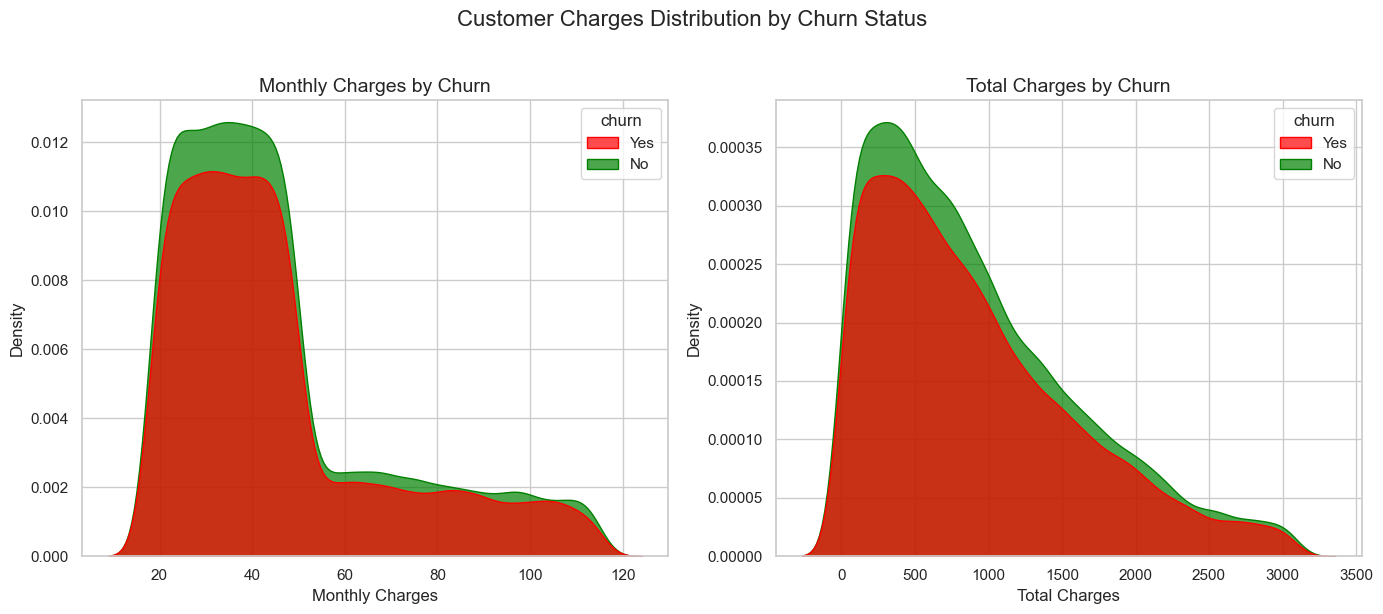

In [84]:
# Set Seaborn style
sns.set(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Plot 1: Monthly Charges
sns.kdeplot(data=df,x="monthly_charges",hue="churn",ax=axes[0],palette={"Yes": "red", "No": "green"},fill=True, alpha=0.7)
axes[0].set_title("Monthly Charges by Churn", fontsize=14)
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Density")

# Plot 2: Total Charges
sns.kdeplot(data=df, x="total_charges",hue="churn",ax=axes[1],palette={"Yes": "red", "No": "green"},fill=True, alpha=0.7)
axes[1].set_title("Total Charges by Churn", fontsize=14)
axes[1].set_xlabel("Total Charges")
axes[1].set_ylabel("Density")


plt.suptitle("Customer Charges Distribution by Churn Status", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


#### 5.2 Plotting total churn count distribution

C:\Users\kapil\AppData\Local\Temp\ipykernel_12576\2986056121.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette={"Yes": "red", "No": "green"},fill=True, alpha=0.7)


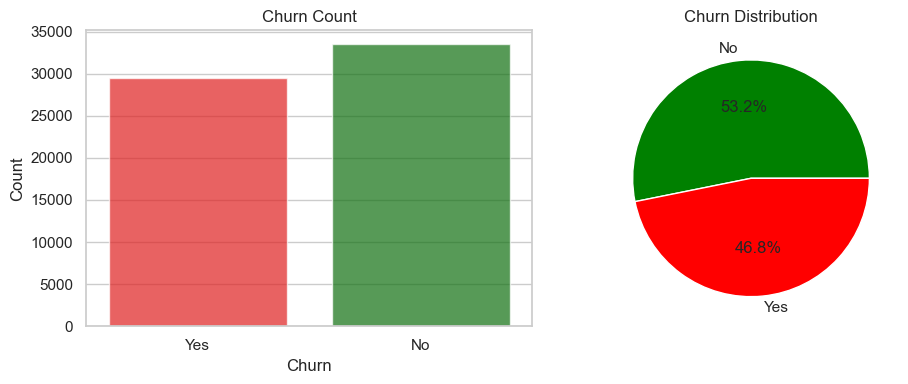

In [85]:
# Set style
sns.set(style="whitegrid")

# Prepare churn data
churn_counts = df['churn'].value_counts()

# Create subplots
plt.figure(figsize=(10, 4))

# Plot 1: Churn Count (Bar Plot)
plt.subplot(1, 2, 1)
sns.countplot(x='churn', data=df, palette={"Yes": "red", "No": "green"},fill=True, alpha=0.7)
plt.title('Churn Count')
plt.xlabel('Churn')
plt.ylabel('Count')

# Plot 2: Churn Distribution (Pie Chart)
plt.subplot(1, 2, 2)
churn_colors = ['green', 'red']
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=churn_colors)
plt.title('Churn Distribution')

plt.tight_layout()
plt.show()


#### 5.3 PLotting Churn by Gender

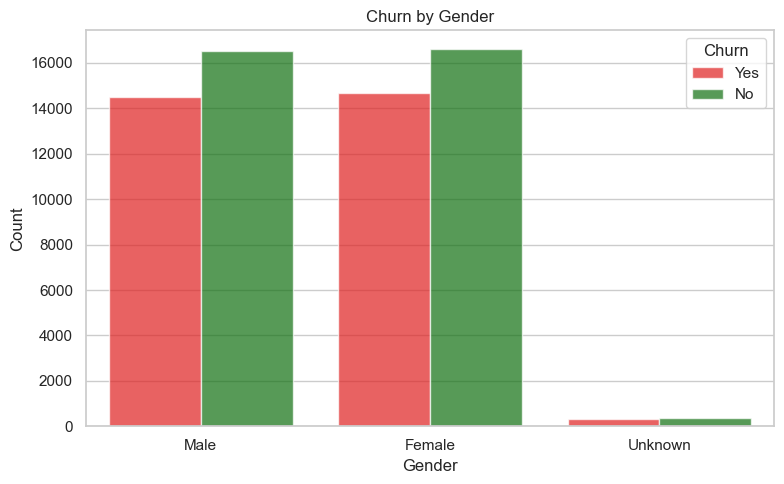

In [86]:
# Set style
sns.set(style="whitegrid")

# Plot churn by gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', hue='churn', palette={'Yes': 'red', 'No': 'green'},alpha=0.7)
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


#### 5.4 Plotting Churn by Internet Service

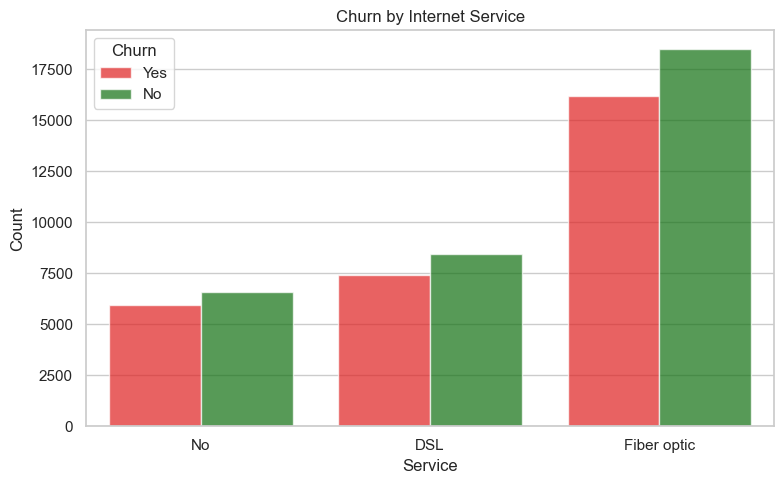

In [87]:
# Set style
sns.set(style="whitegrid")

# Plot churn by gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='internet_service', hue='churn', palette={'Yes': 'red', 'No': 'green'},alpha=0.7)
plt.title('Churn by Internet Service')
plt.xlabel('Service')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


#### 5.5 Plotting Churn by Contract

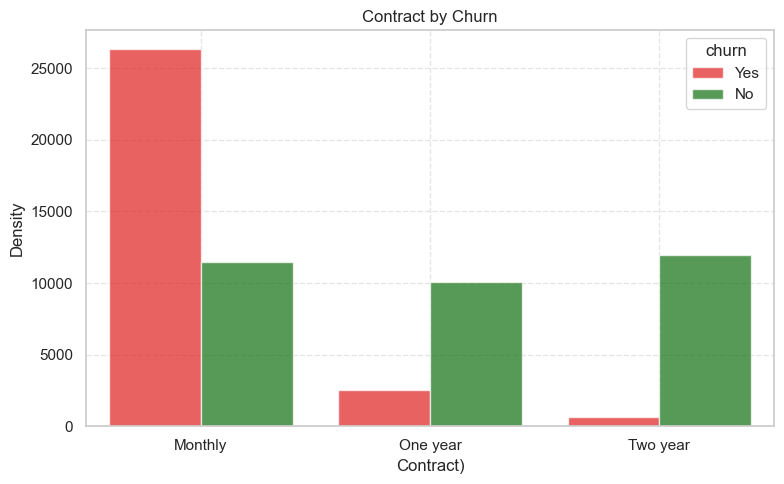

In [88]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contract', hue='churn', fill=True, palette={'Yes': 'red', 'No': 'green'}, alpha=0.7)
plt.title('Contract by Churn')
plt.xlabel('Contract)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



#### 5.6 Plotting Churn by senior citizen

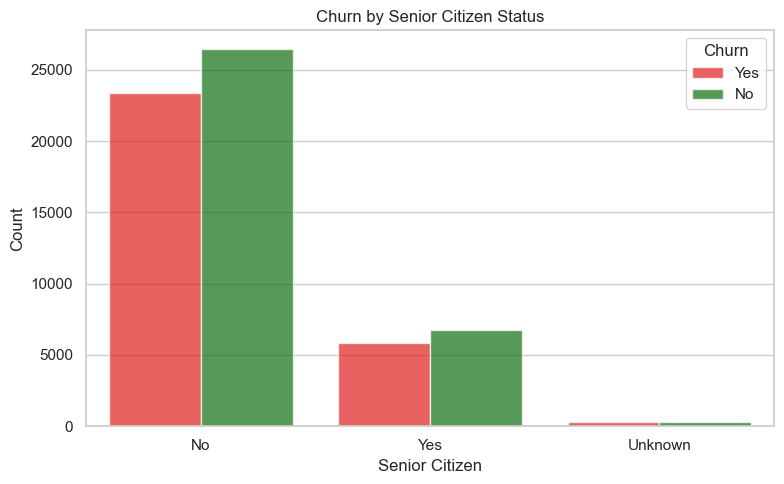

In [89]:

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='senior_citizen', hue='churn', palette={'Yes': 'red', 'No': 'green'}, alpha=0.7)
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


#### 5.7 Plotting Churn by Paperless Billing

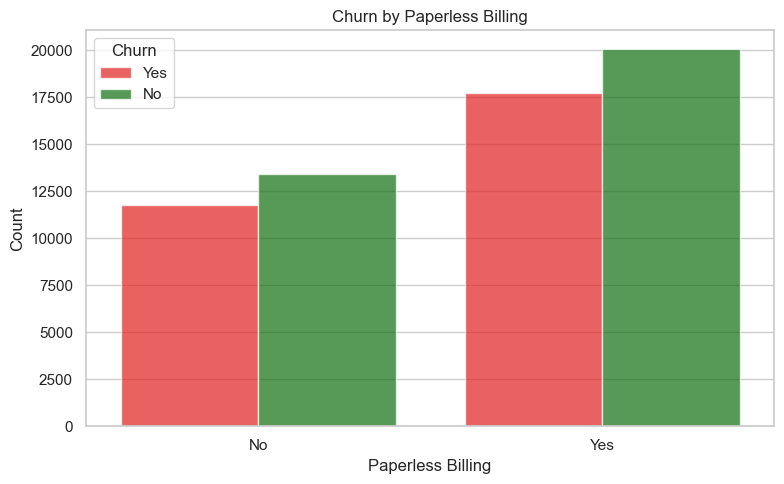

In [90]:
# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='paperless_billing', hue='churn', palette={'Yes': 'red', 'No': 'green'},alpha =0.7)
plt.title('Churn by Paperless Billing')
plt.xlabel('Paperless Billing')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

#### 5.8 Plotting Churn by Engagement score

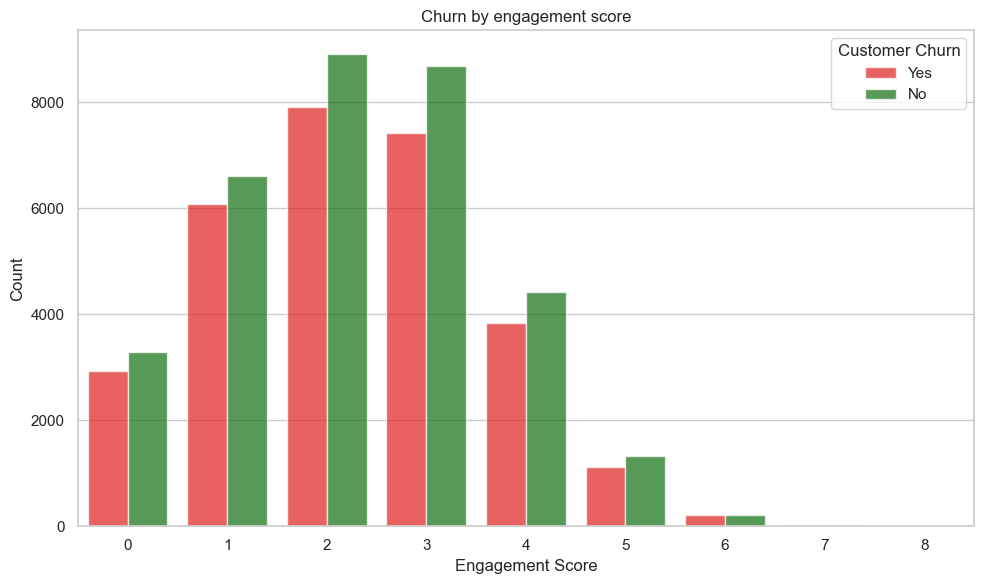

In [91]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='engagement_score',
    hue='churn',
    palette={'No': 'green', 'Yes': 'red'},   # match actual string values
    alpha=0.7
)
plt.title('Churn by engagement score')
plt.xlabel('Engagement Score')
plt.ylabel('Count')
plt.legend(title='Customer Churn')  # clearer legend title
plt.tight_layout()
plt.show()


#### 5.9 correlation heatmap

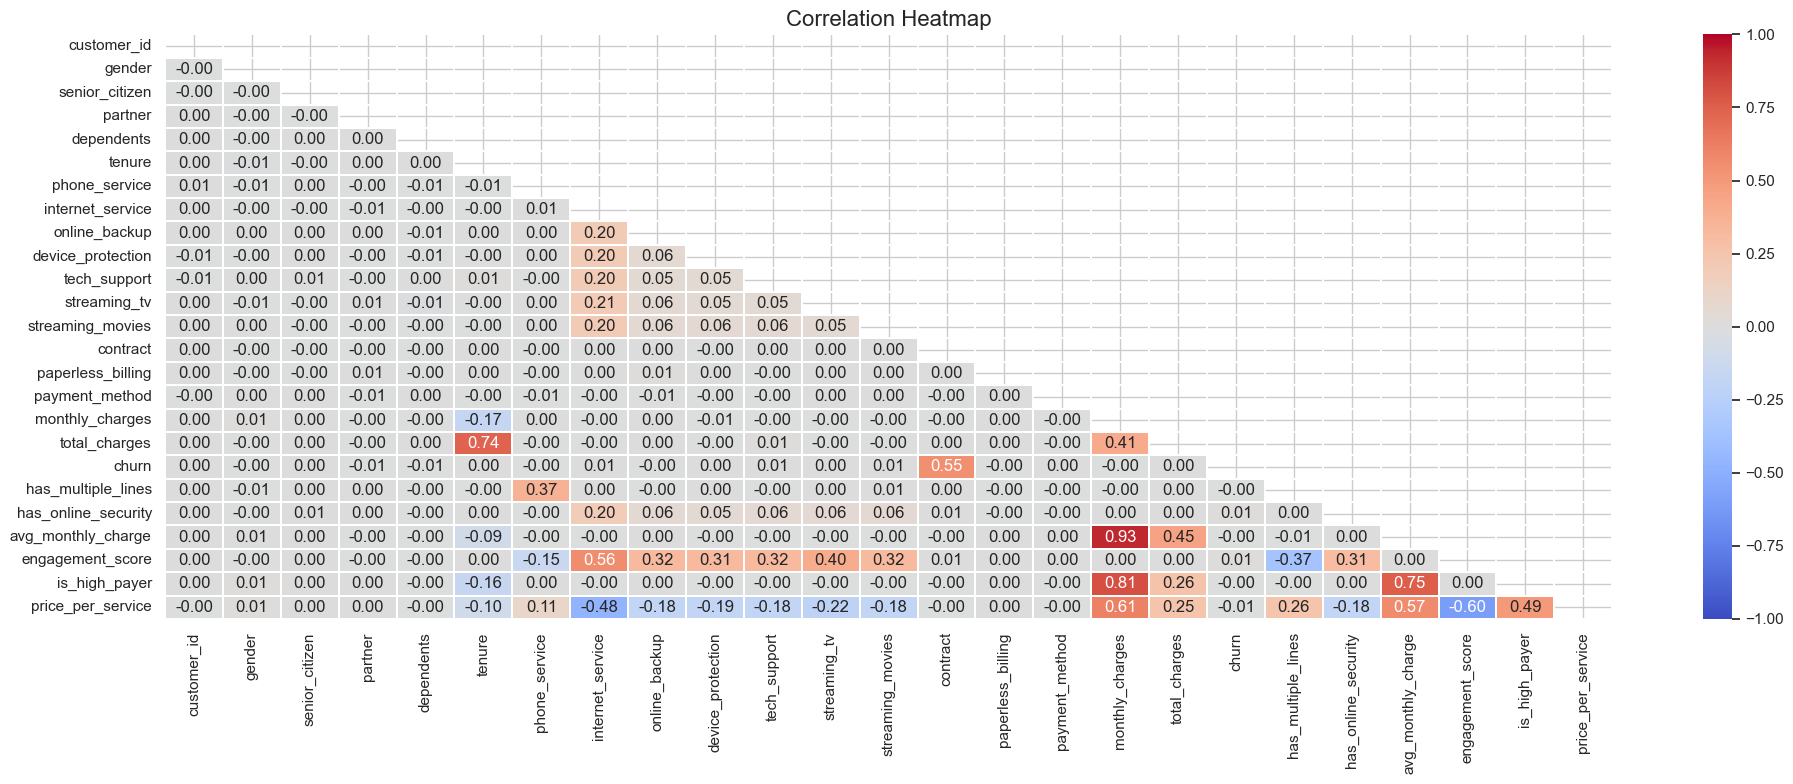

In [92]:
# Make a copy of dataset for computing
df_copy = df.copy()

# Convert categorical/object columns to numeric codes
for col in df_copy.select_dtypes(include=['object']).columns:
    df_copy[col] = pd.factorize(df_copy[col])[0]

# Compute correlation matrix (only numeric columns)
corr = df_copy.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Plot heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.2, vmin=-1, vmax=1)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


## 6. Modelling

#### 6.1 Data Preparation / Train-test split

In [93]:
# Map churn column to binary (Yes=1, No=0)
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

In [94]:
# Separate target variable from features
X = df.drop('churn', axis=1)
y = df['churn']

In [95]:
# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

In [96]:
# Build preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])


In [97]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


#### 6.2 Initializing models

In [98]:
#Define models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42)
}



#### 6.3 Training models, predicting and evaluating scores

In [99]:
# Train, predict, and evaluate
results = []
roc_curves = {}
conf_matrices = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', clf)])
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    results.append([name, acc, prec, rec, f1, roc_auc])
    
    # Save ROC curve data
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[name] = (fpr, tpr, roc_auc)
    
    # Save confusion matrix
    conf_matrices[name] = confusion_matrix(y_test, y_pred)


In [100]:
# Results table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print(results_df)


                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.769194   0.697884  0.894389  0.784011  0.790747
1        Random Forest  0.768241   0.697613  0.891677  0.782796  0.789836
2                  KNN  0.689321   0.651742  0.723004  0.685526  0.732955
3    Gradient Boosting  0.768956   0.697764  0.893880  0.783740  0.791204


#### 6.4 ROC Curve plot

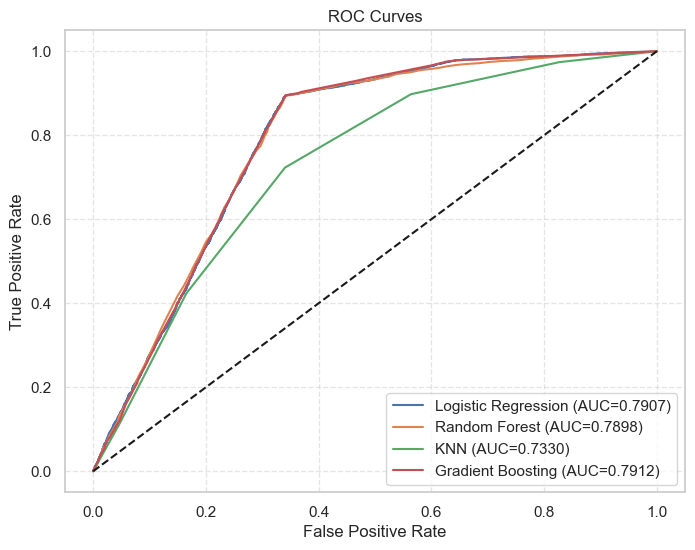

In [101]:
# Plot ROC curves
plt.figure(figsize=(8,6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 6.5 Confusion matrix plot

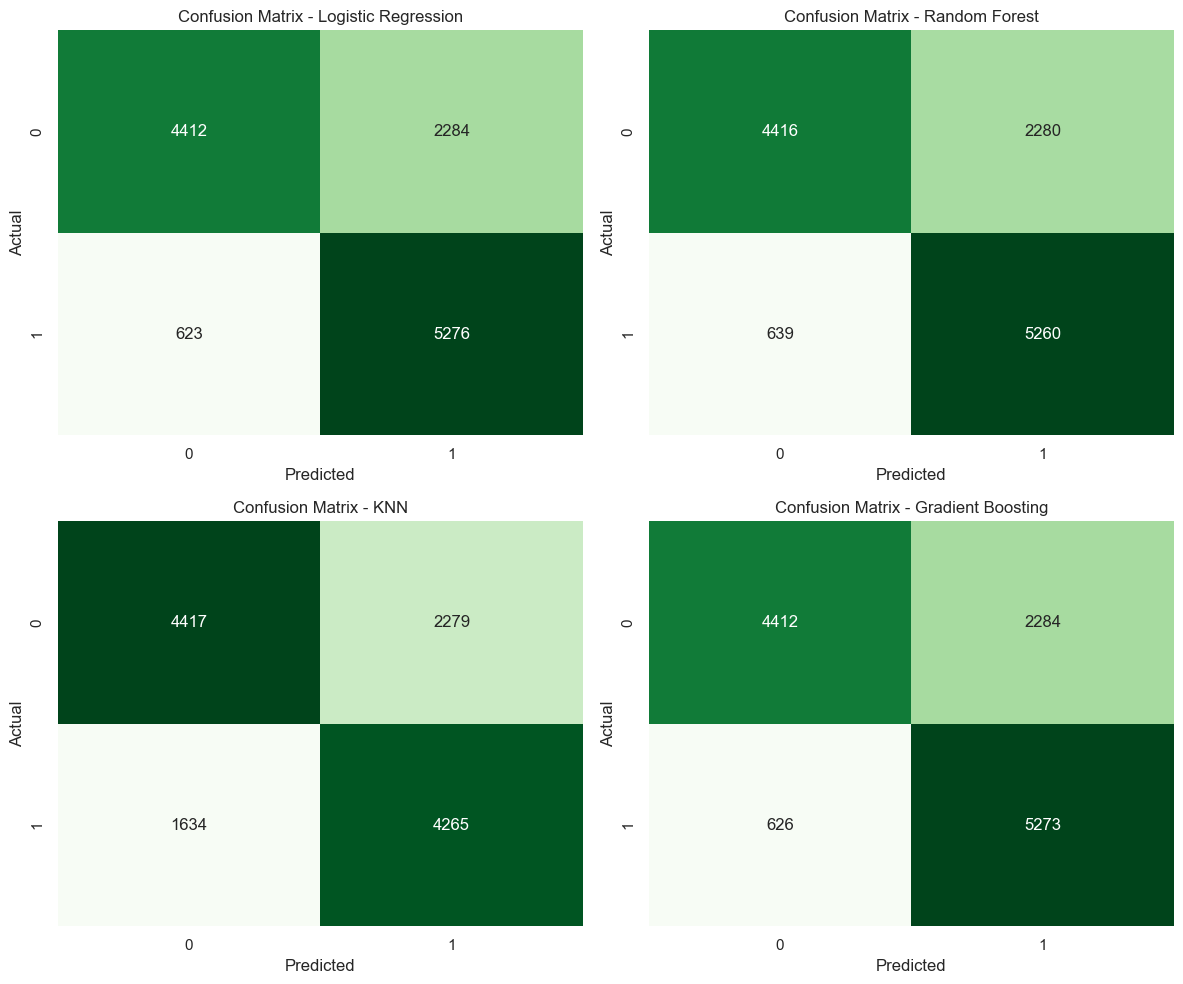

In [102]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning / GridSearch

#### 7.1 Initializing models 

In [103]:
param_grids = {
    "Logistic Regression": {
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['saga', 'lbfgs'],
        'classifier__max_iter': [1000, 2000]
    },
    "Random Forest": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5],
        'classifier__n_jobs': [-1]
    },
    "Gradient Boosting": {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5]
    },
    "KNN": {
        'classifier__n_neighbors': [3, 5, 7, 11],
        'classifier__weights': ['uniform', 'distance']
    }
}

#### 7.2 Training, predicting, tuneing and evaluating scores

In [104]:
# Train, tune, and evaluate with GridSearchCV
results = []
roc_curves = {}
conf_matrices = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', clf)])
    
    grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    
    results.append([name, grid.best_params_, acc, prec, rec, f1, roc_auc])
    
    # Save ROC curve data
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[name] = (fpr, tpr, roc_auc)
    
    # Save confusion matrix
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# Results table
results_df = pd.DataFrame(results, columns=["Model", "Best Params", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print(results_df)


                 Model                                        Best Params  \
0  Logistic Regression  {'classifier__C': 0.1, 'classifier__max_iter':...   
1        Random Forest  {'classifier__max_depth': None, 'classifier__m...   
2                  KNN  {'classifier__n_neighbors': 11, 'classifier__w...   
3    Gradient Boosting  {'classifier__learning_rate': 0.1, 'classifier...   

   Accuracy  Precision    Recall        F1   ROC-AUC  
0  0.769194   0.697884  0.894389  0.784011  0.790698  
1  0.769035   0.697804  0.894050  0.783830  0.789253  
2  0.720365   0.672622  0.785048  0.724499  0.761117  
3  0.768956   0.697764  0.893880  0.783740  0.791204  


#### 7.3 ROC Curve

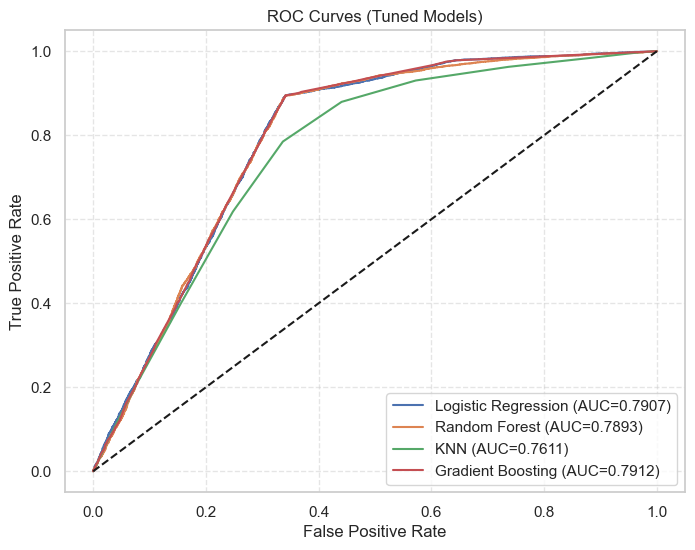

In [105]:
# Plot ROC curves
plt.figure(figsize=(8,6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Tuned Models)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### 7.4 Confusion matrix plot

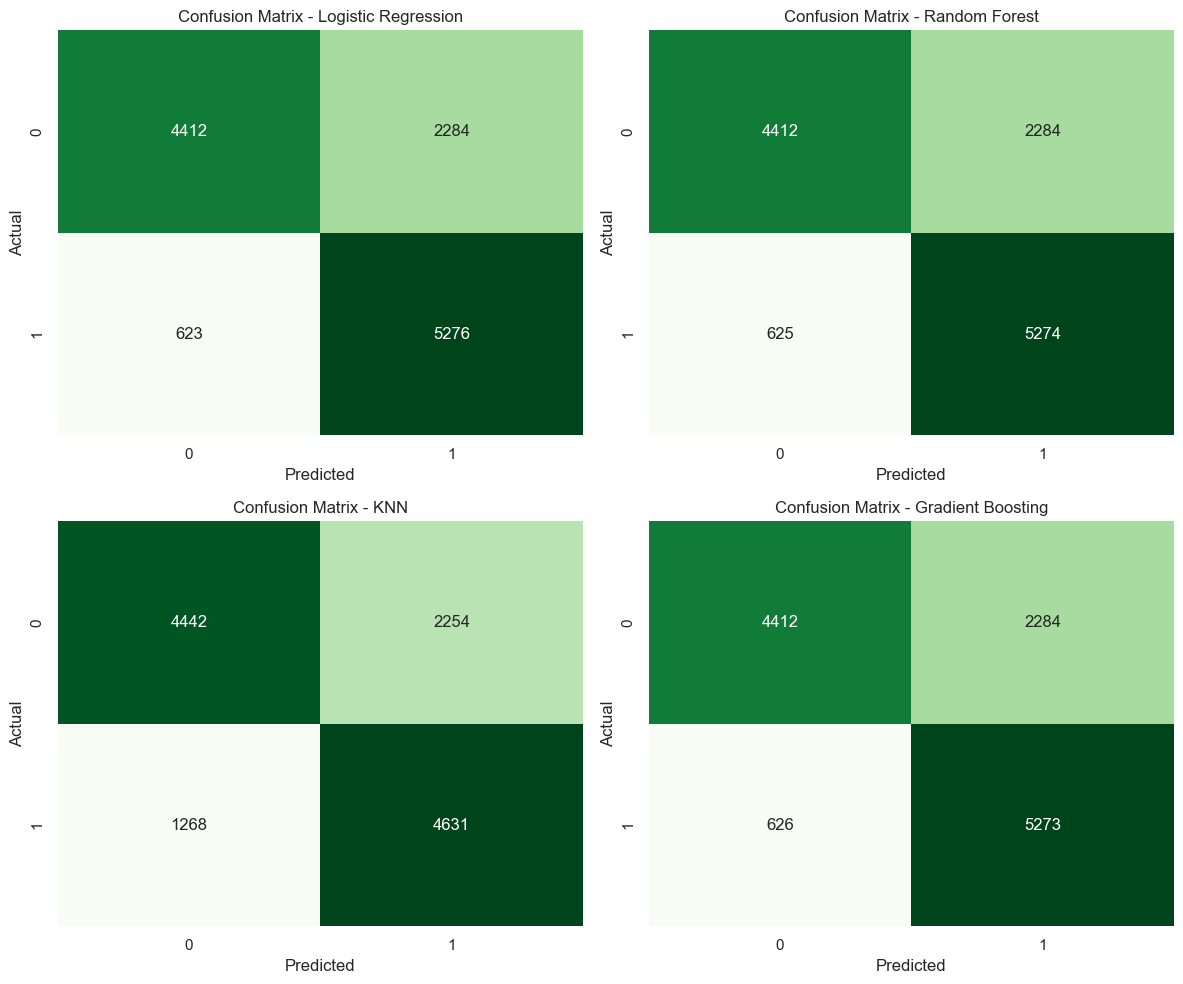

In [106]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 8. Comparison between models

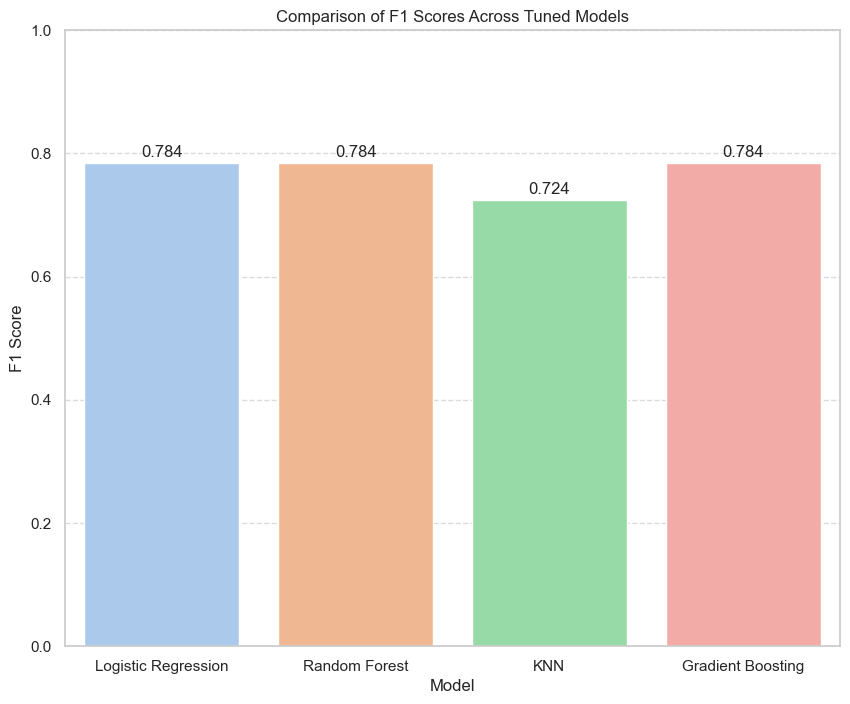

In [107]:
# Bar chart comparing F1 scores across tuned models
plt.figure(figsize=(10,8))
sns.barplot(x="Model", y="F1", hue="Model", data=results_df, palette="pastel", legend=False)
plt.title("Comparison of F1 Scores Across Tuned Models")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values
for index, row in results_df.iterrows():
    plt.text(index, row["F1"] + 0.01, f"{row['F1']:.3f}", ha='center')

plt.show()

### Explanation:

- Comparative analysis of four tuned machine learning models for churn prediction shows that Gradient Boosting delivers the strongest overall performance, achieving the highest ROC‑AUC (0.791) while maintaining balanced precision (0.698), recall (0.894), and F1 score (0.784). 

- Logistic Regression performs nearly identically, offering the added advantage of interpretability through coefficients.

- Random Forest also matches these results and provides valuable feature importance insights, though with slightly lower ROC‑AUC. 

- KNN, while intuitive, underperforms on this dataset due to its computational demands and weaker generalization. 

##### Based on these findings, we recommend Gradient Boosting as the primary model for deployment, supported by Logistic Regression for interpretability and Random Forest for feature exploration. Adding it all together in an ensamble method could be possibility in the future to get a better prediction.